In [1]:
import requests
import pandas as pd
from io import StringIO
import re
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("default")
%config InlineBackend.figure_format = "retina"

In [2]:
posts = requests.get("https://ix.cnn.io/data/truth-social/truth_archive.csv")

In [3]:
posts_df = pd.read_csv(
    StringIO(posts.content.decode("utf-8"))
)

In [4]:
posts_df["created_at"] = pd.to_datetime(posts_df["created_at"])

In [5]:
posts_df

,id,created_at,content,url,media,replies_count,reblogs_count,favourites_count
0,116929732753891262,2026-07-16 12:48:47.296000+00:00,NaN,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,1389,3085,10181
1,116928021654827754,2026-07-16 05:33:37.992000+00:00,NaN,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,1015,3372,14758
2,116928008726091908,2026-07-16 05:30:20.715000+00:00,NaN,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,504,3267,12857
3,116927914613324285,2026-07-16 05:06:24.603000+00:00,https://www.breitbart.com/politics/2026/07/15/...,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,517,3009,13304
4,116927910243652851,2026-07-16 05:05:17.922000+00:00,https://www.breitbart.com/politics/2026/07/15/...,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,307,2597,11694
...,...,...,...,...,...,...,...,...
34711,108221053884053060,2022-04-30 12:37:13.451000+00:00,@melmul,https://truthsocial.com/@realDonaldTrump/10822...,NaN,889,4302,21853
34712,108221053343991942,2022-04-30 12:37:05.206000+00:00,RT @catturd2Joe Biden is going to fly gas guzz...,https://truthsocial.com/@realDonaldTrump/10822...,NaN,0,0,0
34713,108217783188791701,2022-04-29 22:45:26.592000+00:00,Thank you to all of the GREAT and BEAUTIFUL Am...,https://truthsocial.com/@realDonaldTrump/10821...,NaN,19641,47614,217254
34714,108211822140637685,2022-04-28 21:29:28.207000+00:00,I’M BACK! #COVFEFE,https://truthsocial.com/@realDonaldTrump/10821...,https://static-assets-1.truthsocial.com/tmtg:p...,60886,123196,410837


In [6]:
def plot_labeled_lines(
        x_values,
        series_dict,
        ylabel="Value",
        xlabel="Date",
        title="",
        ylim_bottom=0,
        ylim_top=None,
        colors=None,
):
    """
    Plot multiple lines with end-of-line labels, event reference lines,
    and consistent styling.

    Parameters
    ----------
    x_values : array-like of datetimes
    series_dict : dict mapping label -> array-like of y-values
    colors : dict, optional
        Mapping from series name -> matplotlib color.
        Example: {"Positive": "green", "Negative": "red"}
    """
    if colors is None:
        colors = {}

    fig, ax = plt.subplots(figsize=(10, 5))

    label_positions = []

    for name, y_series in series_dict.items():
        line, = ax.plot(
            x_values,
            y_series,
            label=name,
            color=colors.get(name)
        )

        last_y = y_series.iloc[-1] if hasattr(y_series, "iloc") else y_series[-1]
        label_positions.append([last_y, name, line.get_color()])

    # Sort by y so we can push overlapping labels apart
    label_positions.sort(key=lambda p: p[0])

    all_y = np.concatenate([np.asarray(y) for y in series_dict.values()])
    data_range = all_y.max() - all_y.min() if all_y.max() > all_y.min() else 1
    min_gap = data_range * 0.05

    for i in range(1, len(label_positions)):
        if label_positions[i][0] - label_positions[i - 1][0] < min_gap:
            label_positions[i][0] = label_positions[i - 1][0] + min_gap

    # Draw labels
    x_label = x_values[-1]
    for y_pos, name, color in label_positions:
        ax.text(
            x_label,
            y_pos,
            f"  {name.title()}",
            color=color,
            va="center",
            fontsize=10,
        )

    if ylim_bottom is not None:
        ax.set_ylim(bottom=ylim_bottom)

    if ylim_top is not None:
        ax.set_ylim(top=ylim_top)

    # Vertical reference lines
    events = [
        (pd.Timestamp("2024-11-05"), "Election"),
        (pd.Timestamp("2025-01-20"), "Inauguration"),
    ]

    for event_date, label in events:
        ax.axvline(event_date, color="gray", linestyle=":", linewidth=1)
        ax.text(
            event_date,
            ax.get_ylim()[1],
            f" {label}",
            color="gray",
            fontsize=9,
            rotation=90,
            va="top",
            ha="left",
        )

    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin, xmax + (xmax - xmin) * 0.15)

    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_title(title)

    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="grey")

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.spines["bottom"].set_color("gray")
    ax.tick_params(axis="x", colors="gray")
    ax.title.set_color("gray")
    ax.xaxis.label.set_color("gray")
    ax.yaxis.label.set_color("gray")
    ax.tick_params(axis="y", colors="gray", labelsize=10, left=False)

    fig.tight_layout()
    plt.show()

In [7]:
def words_over_time(df, words):
    df = df.copy()

    df["month"] = df["created_at"].dt.tz_localize(None).dt.to_period("M")
    df = df.dropna(subset=["created_at", "content"])

    words = [w.lower() for w in words]

    # Lowercase and remove punctuation
    df["tokens"] = (
        df["content"]
        .str.lower()
        .apply(lambda s: re.findall(r"[a-z]+(?:'[a-z]+)?", s))
    )

    # Total words per post
    df["word_count"] = df["tokens"].str.len()

    # Count each target word
    for word in words:
        df[word] = df["tokens"].apply(lambda tokens: tokens.count(word))

    # Aggregate by month
    monthly = df.groupby("month")[["word_count"] + words].sum()

    # Convert counts to occurrences per 1000 words
    for word in words:
        monthly[word + "_per_1000"] = (
            1000 * monthly[word] / monthly["word_count"]
        )

    x_values = monthly.index.to_timestamp()
    series_dict = {word: monthly[word + "_per_1000"] for word in words}

    plot_labeled_lines(
        x_values,
        series_dict,
        ylabel="Occurrences per 1,000 words",
        xlabel="Date",
        title="Trump Truth Social Posts\nWord Occurrence Rate by Month"
    )

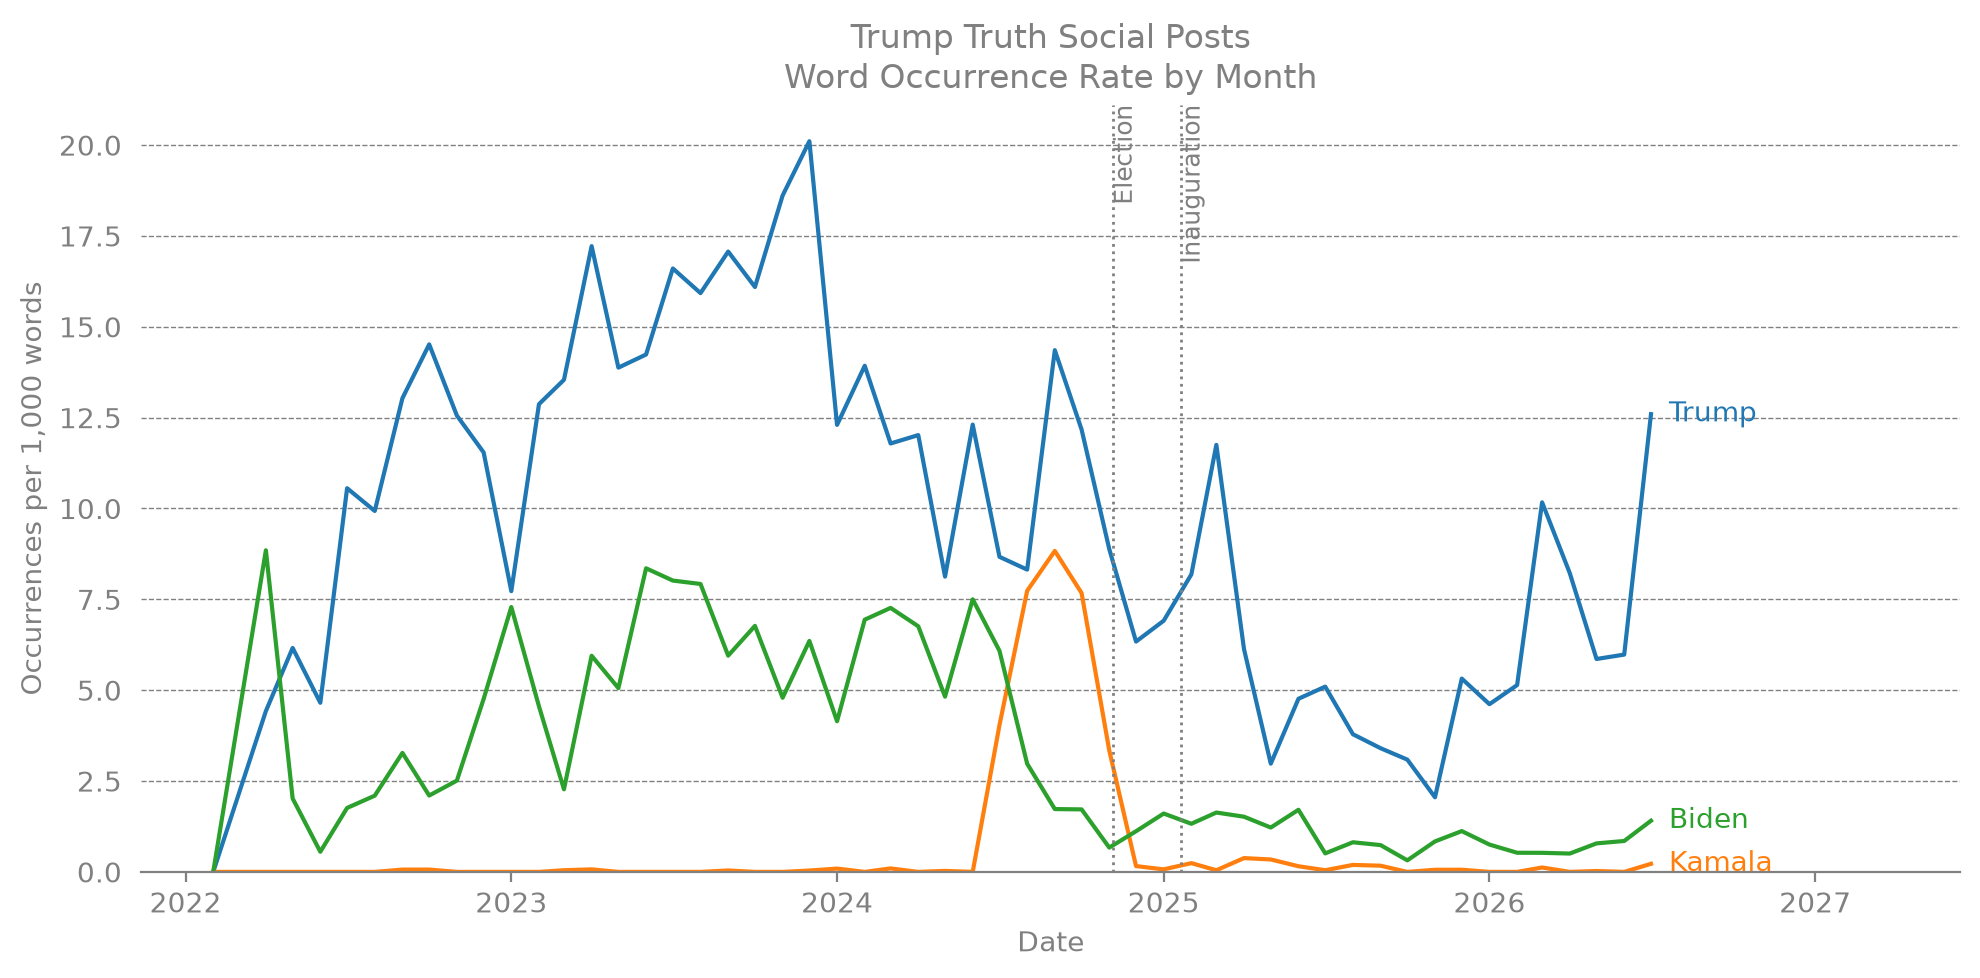

In [8]:
words_over_time(posts_df, ["trump", "kamala", "biden"])

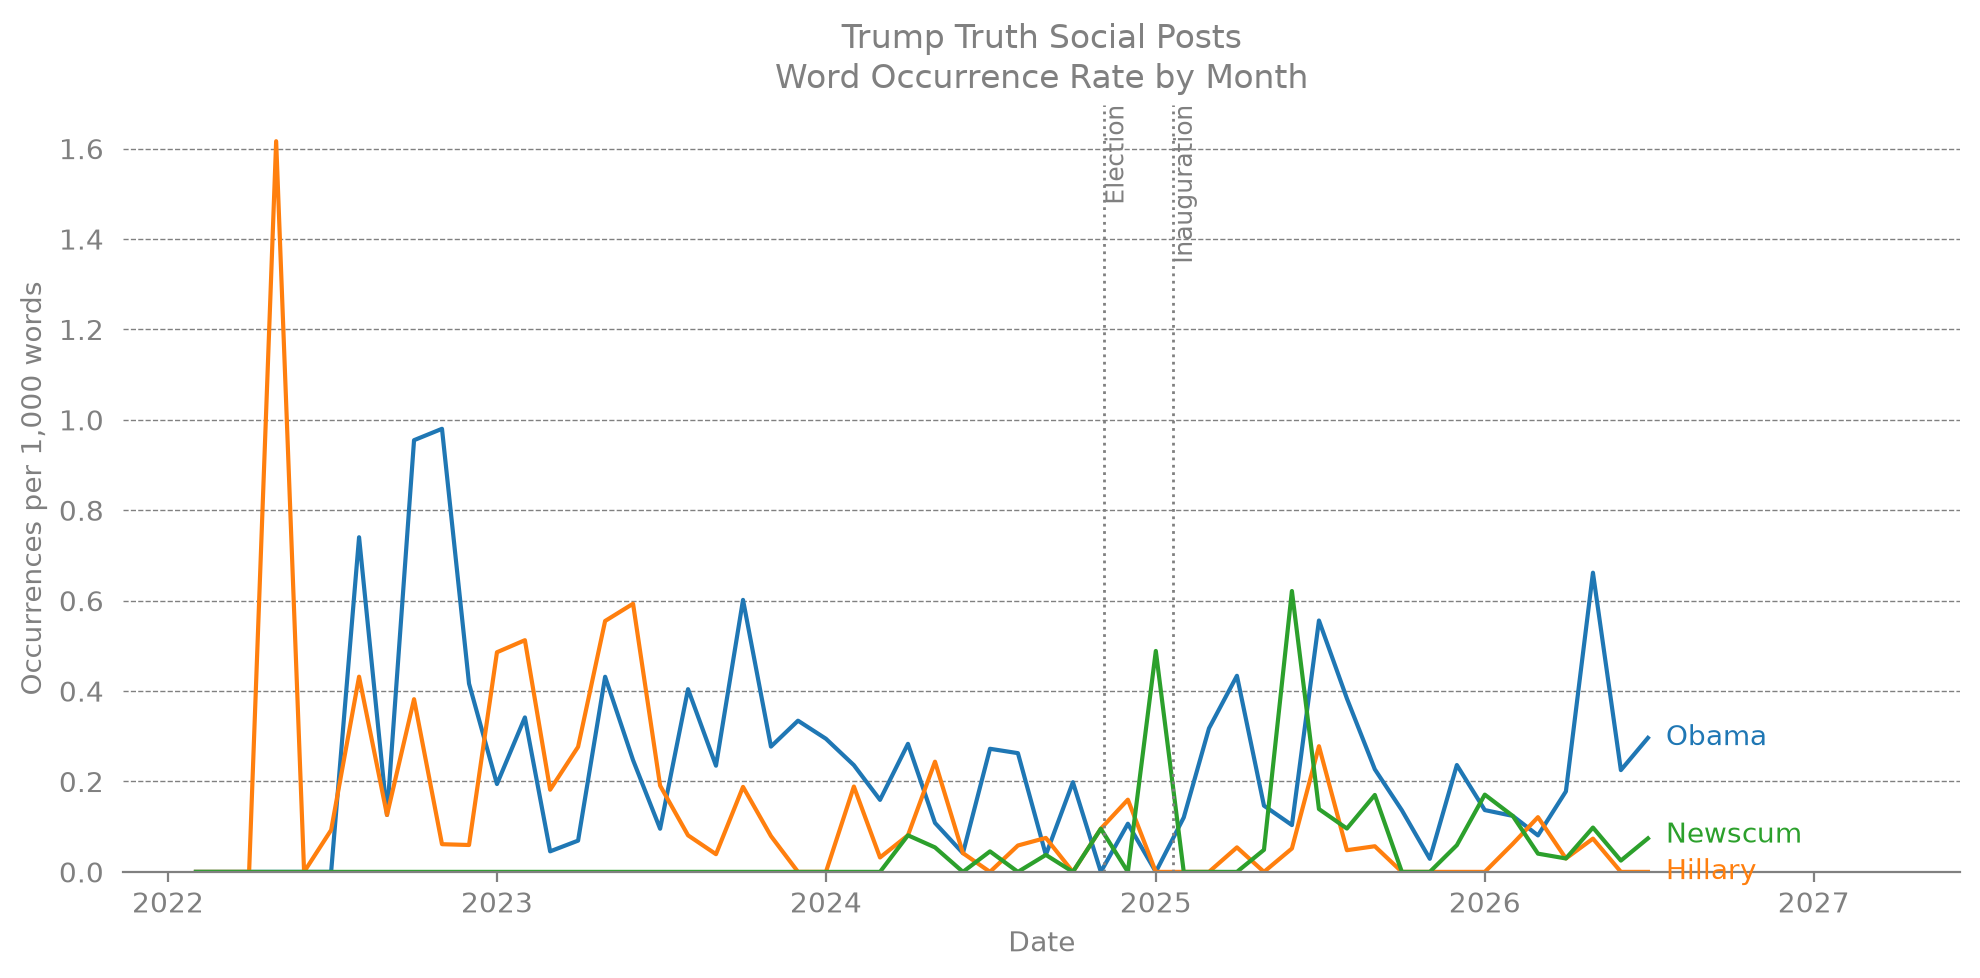

In [9]:
words_over_time(posts_df, ["obama", "hillary", "newscum"])

## VADER Sentiment Analysis

In [10]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\d8amo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [11]:
sia = SentimentIntensityAnalyzer()


def get_vader_sentiment(text):
    if pd.isna(text):
        return pd.Series({
            "neg": pd.NA,
            "neu": pd.NA,
            "pos": pd.NA
        })
    scores = sia.polarity_scores(text)
    return pd.Series({
        "neg": scores["neg"],
        "neu": scores["neu"],
        "pos": scores["pos"],
        "compound": scores["compound"]
    })


def analyze_vader_sentiment(df):
    df = df.copy()

    df[["neg", "neu", "pos", "compound"]] = df["content"].apply(get_vader_sentiment)

    return df

In [12]:
vader_sentiment_df = analyze_vader_sentiment(posts_df)

In [13]:
vader_sentiment_df

,id,created_at,content,url,media,replies_count,reblogs_count,favourites_count,neg,neu,pos,compound
0,116929732753891262,2026-07-16 12:48:47.296000+00:00,NaN,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,1389,3085,10181,<NA>,<NA>,<NA>,NaN
1,116928021654827754,2026-07-16 05:33:37.992000+00:00,NaN,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,1015,3372,14758,<NA>,<NA>,<NA>,NaN
2,116928008726091908,2026-07-16 05:30:20.715000+00:00,NaN,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,504,3267,12857,<NA>,<NA>,<NA>,NaN
3,116927914613324285,2026-07-16 05:06:24.603000+00:00,https://www.breitbart.com/politics/2026/07/15/...,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,517,3009,13304,0.0,1.0,0.0,0.0000
4,116927910243652851,2026-07-16 05:05:17.922000+00:00,https://www.breitbart.com/politics/2026/07/15/...,https://truthsocial.com/@realDonaldTrump/11692...,https://static-assets-1.truthsocial.com/tmtg:p...,307,2597,11694,0.0,1.0,0.0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
34711,108221053884053060,2022-04-30 12:37:13.451000+00:00,@melmul,https://truthsocial.com/@realDonaldTrump/10822...,NaN,889,4302,21853,0.0,1.0,0.0,0.0000
34712,108221053343991942,2022-04-30 12:37:05.206000+00:00,RT @catturd2Joe Biden is going to fly gas guzz...,https://truthsocial.com/@realDonaldTrump/10822...,NaN,0,0,0,0.117,0.883,0.0,-0.6428
34713,108217783188791701,2022-04-29 22:45:26.592000+00:00,Thank you to all of the GREAT and BEAUTIFUL Am...,https://truthsocial.com/@realDonaldTrump/10821...,NaN,19641,47614,217254,0.084,0.574,0.342,0.9600
34714,108211822140637685,2022-04-28 21:29:28.207000+00:00,I’M BACK! #COVFEFE,https://truthsocial.com/@realDonaldTrump/10821...,https://static-assets-1.truthsocial.com/tmtg:p...,60886,123196,410837,0.0,1.0,0.0,0.0000


In [14]:
def sentiment_over_months(df, compound=True, method="VADER"):
    df["month"] = df["created_at"].dt.tz_localize(None).dt.to_period("M")

    drop_list = ["created_at", "neg", "neu", "pos"]
    if compound:
        drop_list.append("compound")

    df = df.dropna(subset=drop_list)

    agg_dict = {
        "neg": "mean",
        "neu": "mean",
        "pos": "mean",
    }

    if compound:
        agg_dict["compound"] = "mean"

    monthly = df.groupby("month", as_index=True).agg(agg_dict)

    sentiments = {
        "Negative": monthly["neg"],
        "Neutral": monthly["neu"],
        "Positive": monthly["pos"]
    }

    plot_labeled_lines(
        monthly.index.to_timestamp(),
        sentiments,
        ylabel="Sentiment",
        xlabel="Date",
        ylim_top=1,
        title=f"Trump Truth Social Posts\nAverage {method} Sentiment by Month",
        colors={
            "Negative": "red",
            "Neutral": "gray",
            "Positive": "green",
        }
    )

    if compound:
        compound = {
            "Compound": monthly["compound"],
        }

        plot_labeled_lines(
            monthly.index.to_timestamp(),
            compound,
            ylim_bottom=None,
            ylim_top=None,
            ylabel="Compound Sentiment",
            xlabel="Date",
            title=f"Trump Truth Social Posts\nAverage {method} Compound Sentiment by Month",
        )

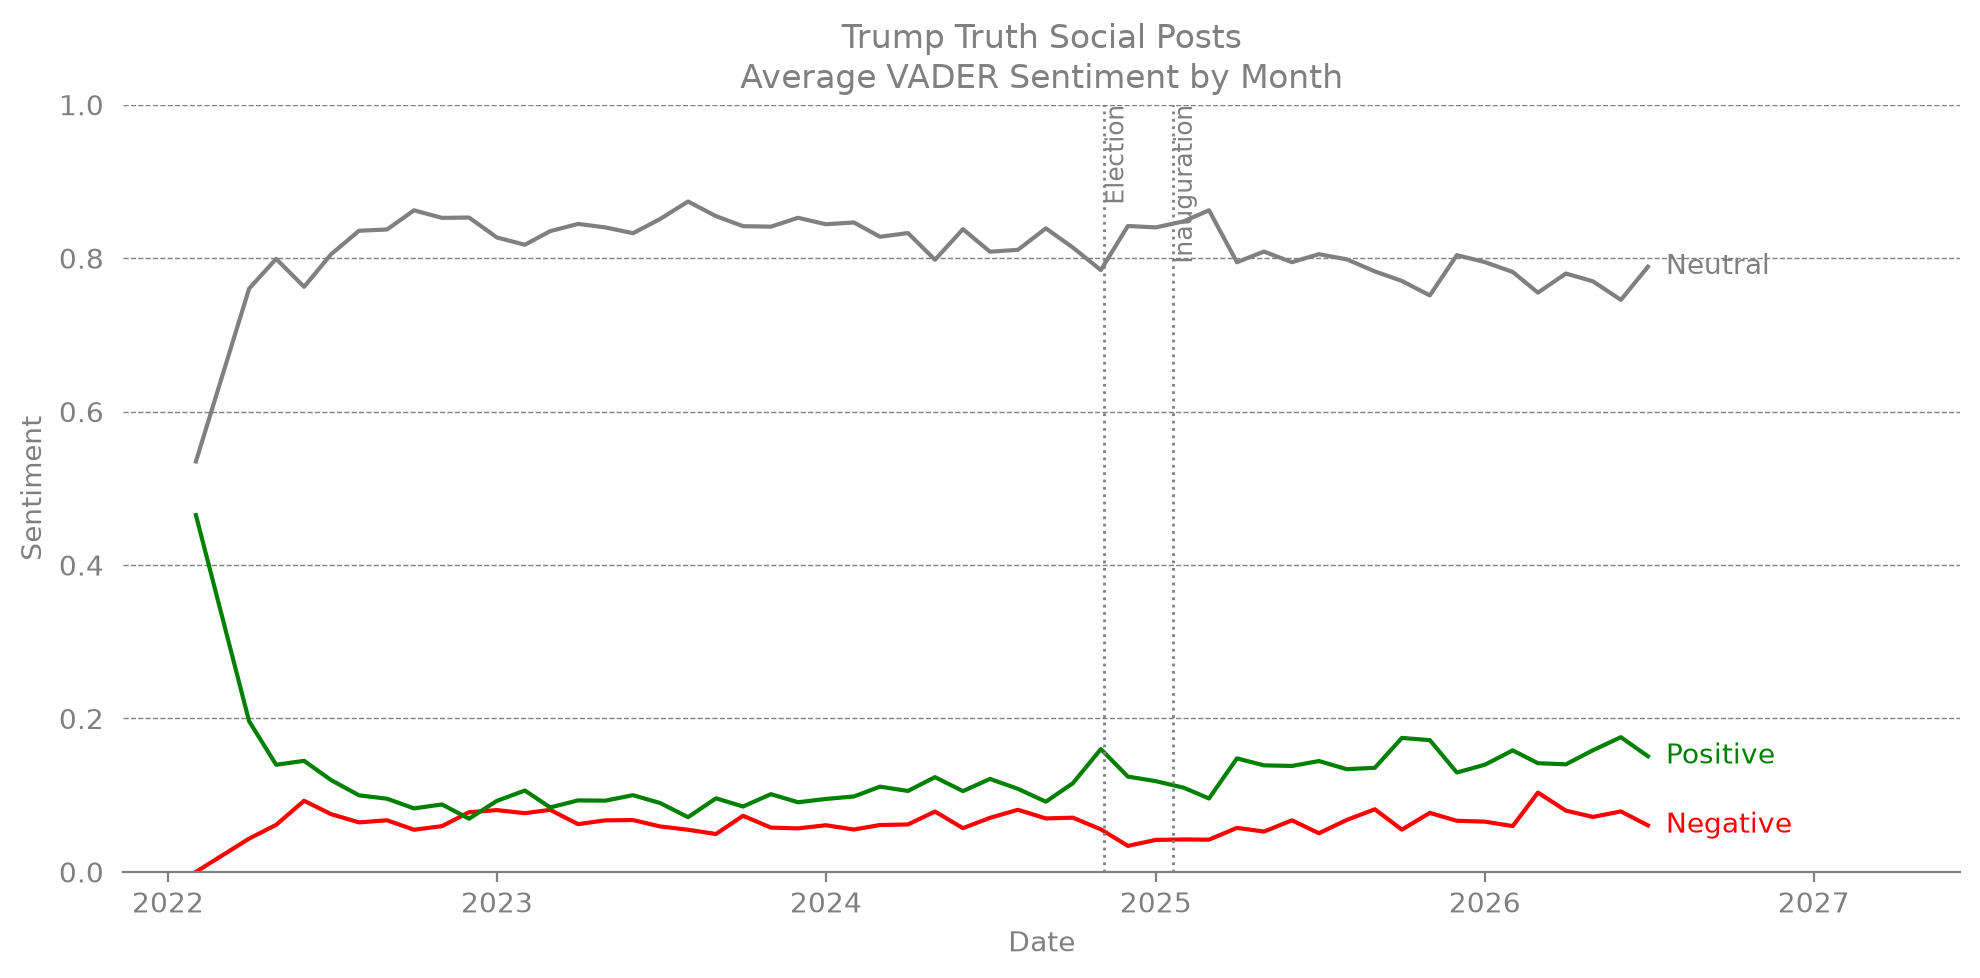

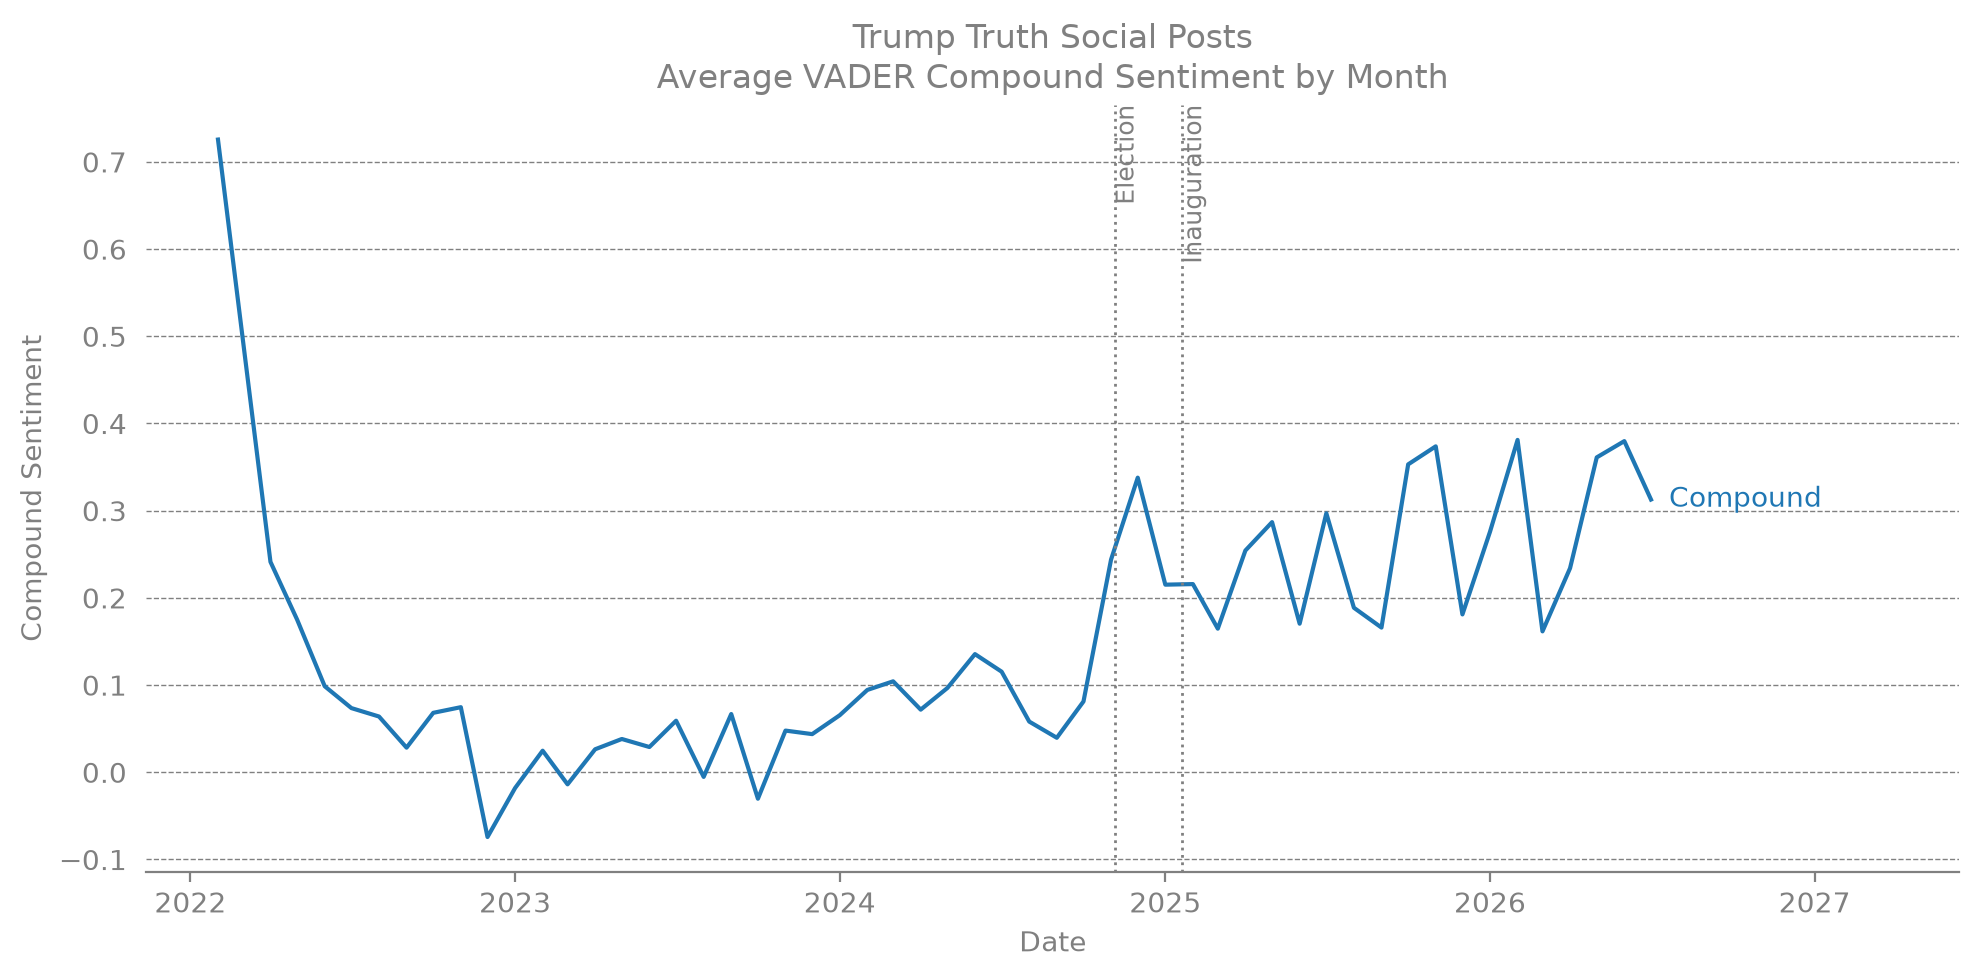

In [15]:
sentiment_over_months(vader_sentiment_df)

## RoBERTa Sentiment

In [16]:
from tqdm.auto import tqdm
tqdm.pandas()


def get_roberta_sentiment(text, classifier):
    if pd.isna(text):
        return pd.Series({
            "negative": None,
            "neutral": None,
            "positive": None
        })

    result = classifier(text)[0]

    scores = {
        item["label"].lower(): item["score"]
        for item in result
    }

    return pd.Series({
        "negative": scores.get("negative"),
        "neutral": scores.get("neutral"),
        "positive": scores.get("positive")
    })


def analyze_roberta_sentiment(df, classifier):
    df = df.copy()

    sentiment = df["content"].progress_apply(
        lambda text: get_roberta_sentiment(text, classifier)
    )

    df[["neg", "neu", "pos"]] = sentiment.rename(columns={
        "negative": "neg",
        "neutral": "neu",
        "positive": "pos"
    })

    return df

C:\Users\d8amo\Desktop\Programming\Python\trump-truth-social-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
from pathlib import Path

cache_file = Path("data/roberta_sentiment_df.parquet")

if cache_file.exists():
    print("Loading cached RoBERTa sentiment...")
    roberta_sentiment_df = pd.read_parquet(cache_file)

else:
    # It's an ugly solution, but if I import torch or transformers then cause any exception the kernel will crash.
    #  So if I import torch only when I need it, I minimize kernel crashes
    #  See more: https://github.com/pytorch/pytorch/issues/178538

    print("Computing RoBERTa sentiment...")
    import torch

    print("PyTorch version:", torch.__version__)
    print("CUDA version:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        print("GPU count:", torch.cuda.device_count())

    from transformers import pipeline

    classifier = pipeline(
        "sentiment-analysis",
        model="cardiffnlp/twitter-roberta-base-sentiment-latest",
        top_k=None,
        truncation=True,
        max_length=512
    )

    roberta_sentiment_df = analyze_roberta_sentiment(posts_df, classifier)

    cache_file.parent.mkdir(parents=True, exist_ok=True)
    roberta_sentiment_df.to_parquet(cache_file)

    print("Saved:", cache_file)

Loading cached RoBERTa sentiment...


In [18]:
roberta_sentiment_df

,id,created_at,content,url,media,replies_count,reblogs_count,favourites_count,neg,neu,pos
0,116887463214588151,2026-07-09 01:39:05.242000+00:00,Thank you to the brilliant and highly respecte...,https://truthsocial.com/@realDonaldTrump/11688...,https://static-assets-1.truthsocial.com/tmtg:p...,1777,5535,22308,0.003420,0.011687,0.984893
1,116887138484719000,2026-07-09 00:16:30.253000+00:00,NaN,https://truthsocial.com/@realDonaldTrump/11688...,https://static-assets-1.truthsocial.com/tmtg:p...,2218,4489,19541,NaN,NaN,NaN
2,116887137680697133,2026-07-09 00:16:17.990000+00:00,NaN,https://truthsocial.com/@realDonaldTrump/11688...,https://static-assets-1.truthsocial.com/tmtg:p...,954,3462,15596,NaN,NaN,NaN
3,116886928331817100,2026-07-08 23:23:03.574000+00:00,The newly revamped West Wing of the White Hous...,https://truthsocial.com/@realDonaldTrump/11688...,https://static-assets-1.truthsocial.com/tmtg:p...,2042,4964,26555,0.002832,0.321856,0.675312
4,116886926110208412,2026-07-08 23:22:29.677000+00:00,Gavin Newscum's recent Career Threatening Inte...,https://truthsocial.com/@realDonaldTrump/11688...,NaN,1427,4980,21499,0.914670,0.076804,0.008526
...,...,...,...,...,...,...,...,...,...,...,...
34544,108221053884053060,2022-04-30 12:37:13.451000+00:00,@melmul,https://truthsocial.com/@realDonaldTrump/10822...,NaN,889,4302,21853,0.106986,0.664937,0.228077
34545,108221053343991942,2022-04-30 12:37:05.206000+00:00,RT @catturd2Joe Biden is going to fly gas guzz...,https://truthsocial.com/@realDonaldTrump/10822...,NaN,0,0,0,0.633965,0.330972,0.035064
34546,108217783188791701,2022-04-29 22:45:26.592000+00:00,Thank you to all of the GREAT and BEAUTIFUL Am...,https://truthsocial.com/@realDonaldTrump/10821...,NaN,19641,47614,217254,0.006630,0.018256,0.975114
34547,108211822140637685,2022-04-28 21:29:28.207000+00:00,IâM BACK! #COVFEFE,https://truthsocial.com/@realDonaldTrump/10821...,https://static-assets-1.truthsocial.com/tmtg:p...,60886,123196,410837,0.003275,0.113611,0.883114


In [19]:
roberta_sentiment_df["compound"] = roberta_sentiment_df["pos"] - roberta_sentiment_df["neg"]

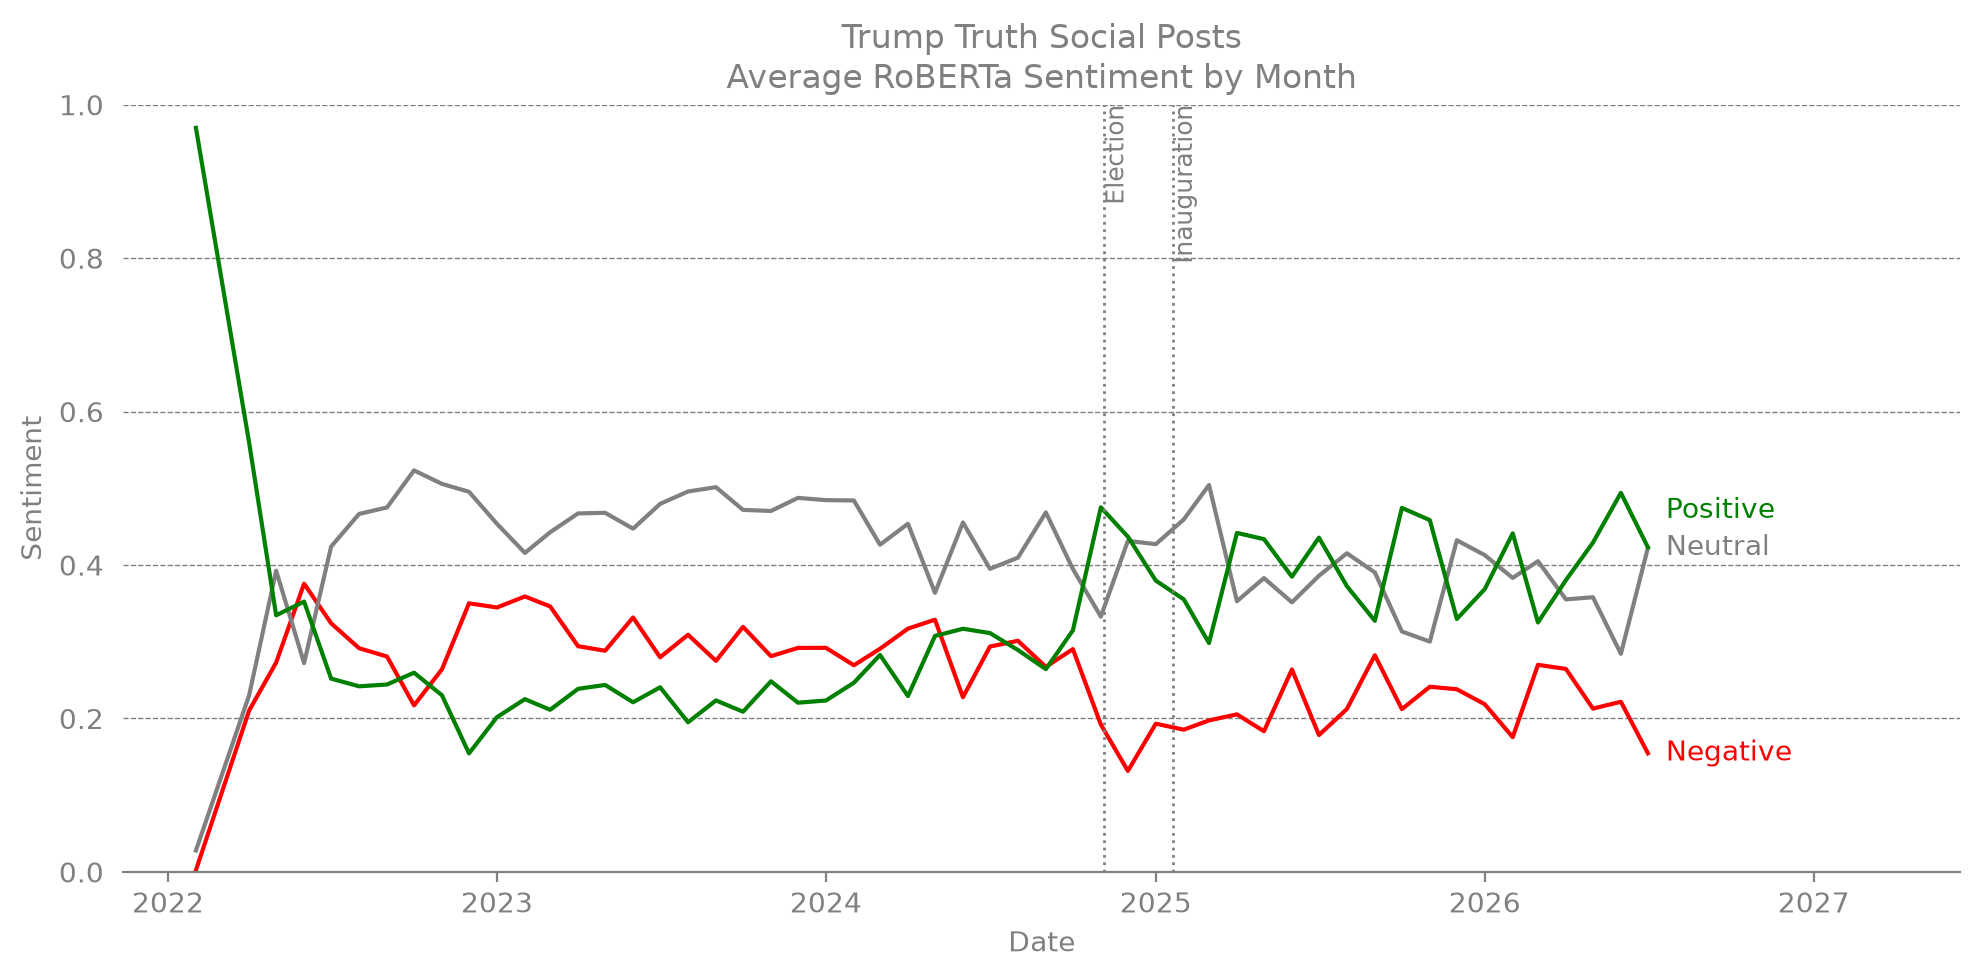

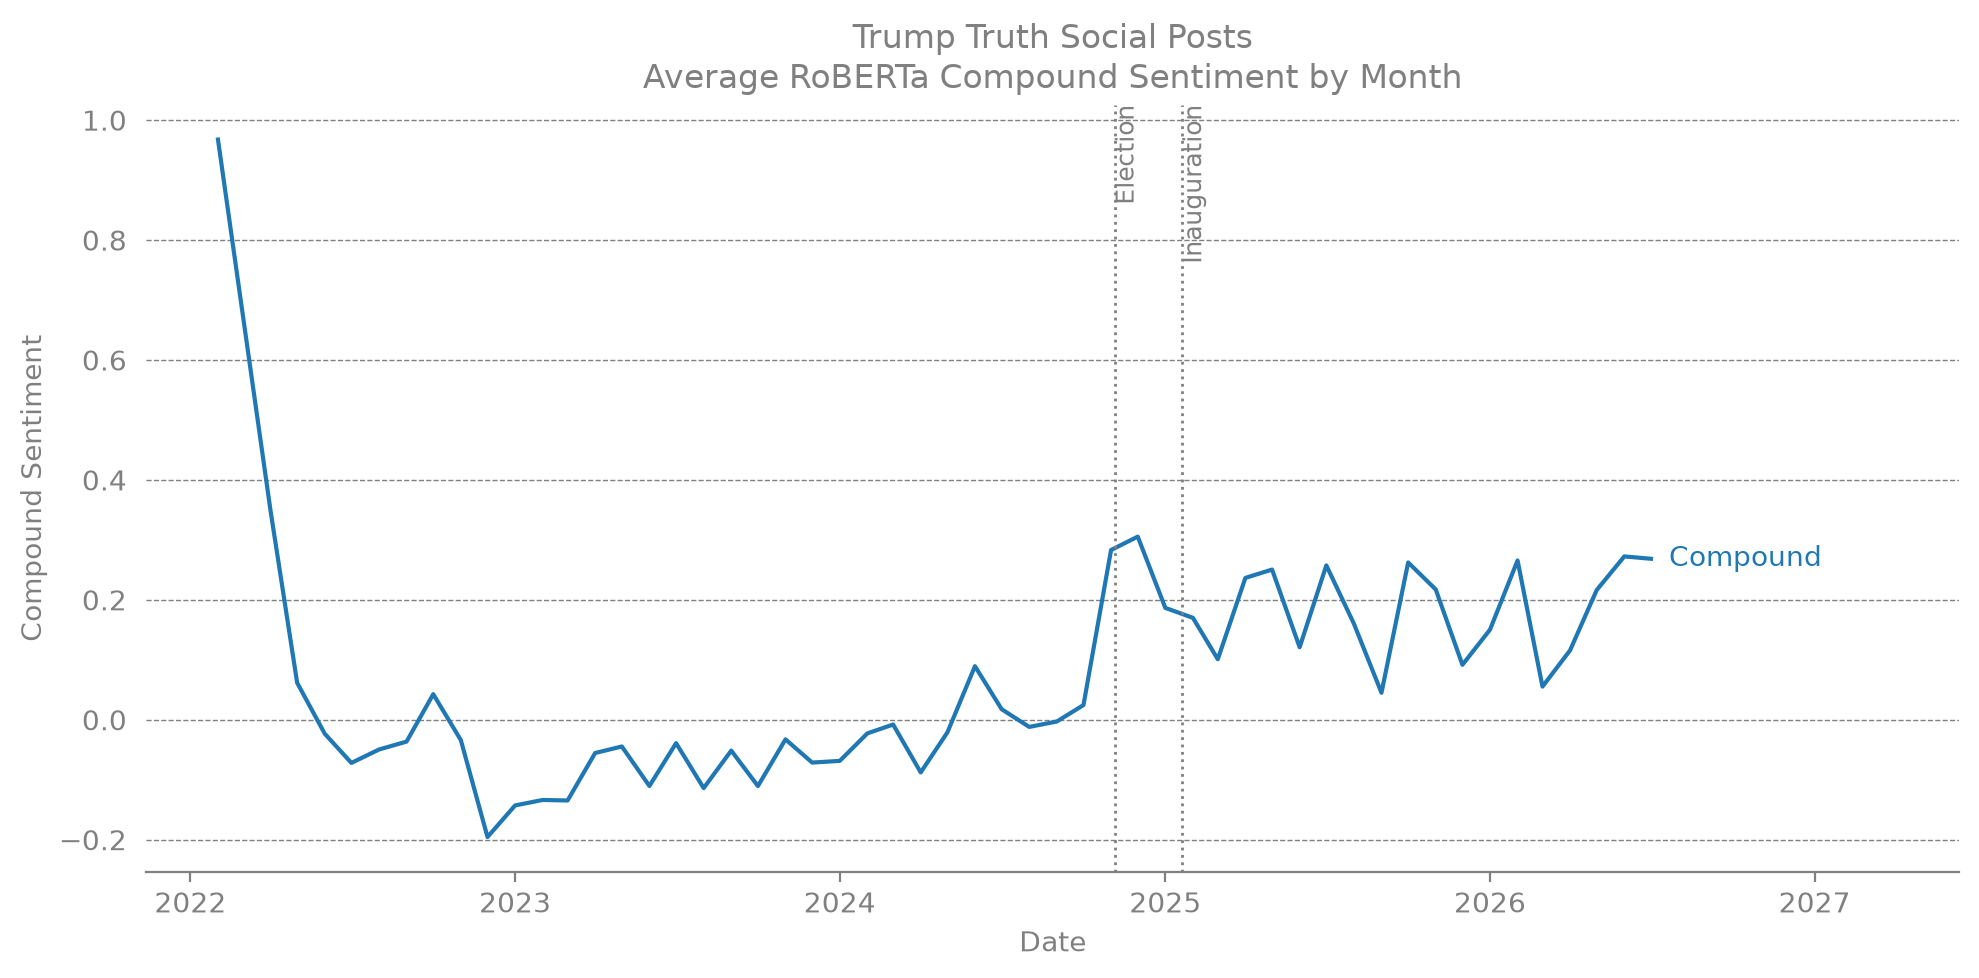

In [20]:
sentiment_over_months(roberta_sentiment_df, method="RoBERTa")

## Sentiment vs. Interaction Correlation

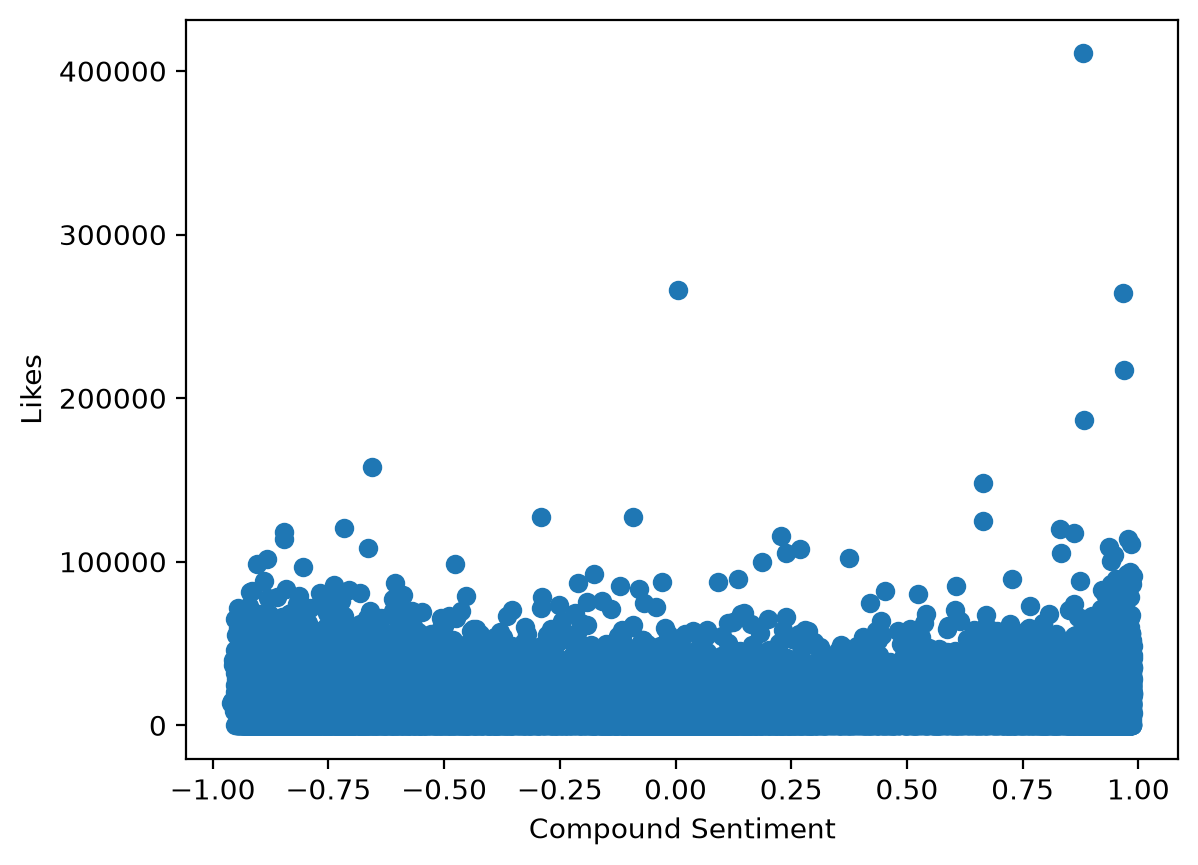

In [21]:
plt.scatter(roberta_sentiment_df["compound"], roberta_sentiment_df["favourites_count"], alpha=1)
plt.xlabel("Compound Sentiment")
plt.ylabel("Likes")
plt.show()

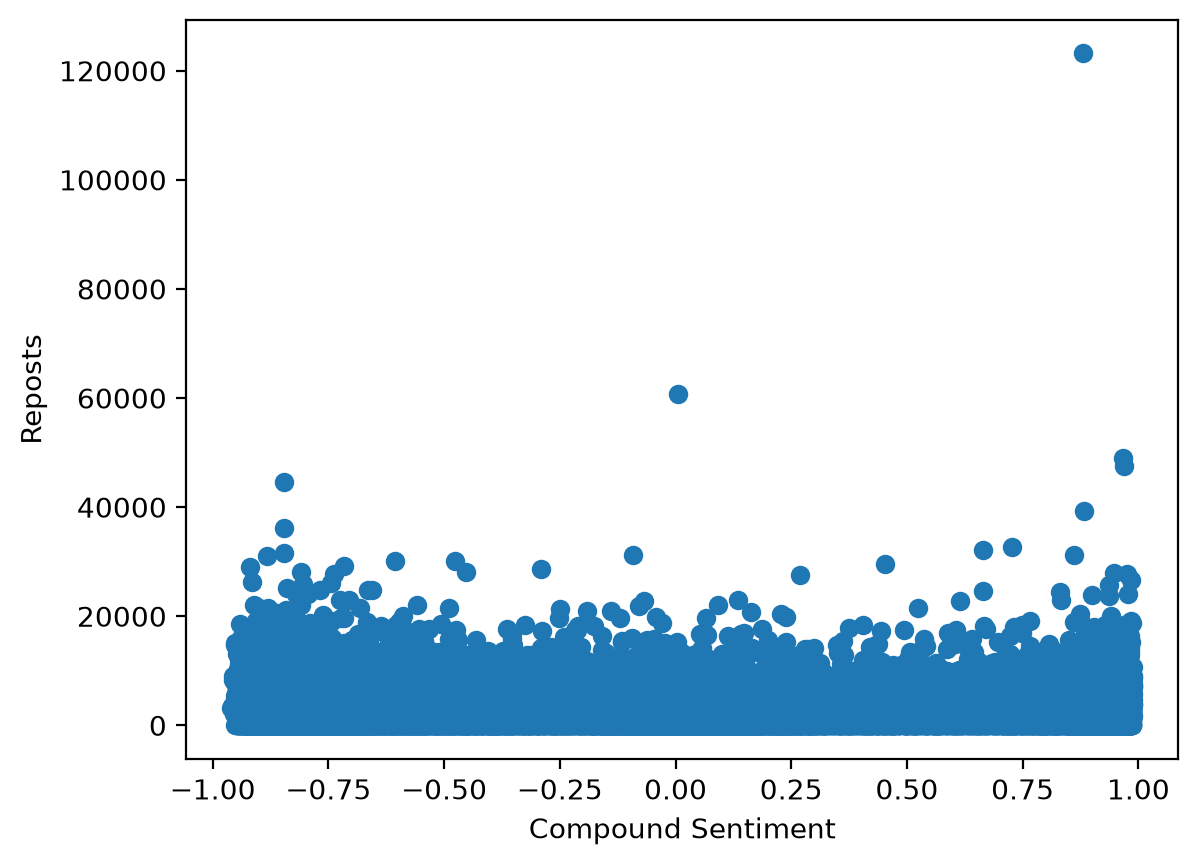

In [22]:
plt.scatter(roberta_sentiment_df["compound"], roberta_sentiment_df["reblogs_count"])
plt.xlabel("Compound Sentiment")
plt.ylabel("Reposts")
plt.show()

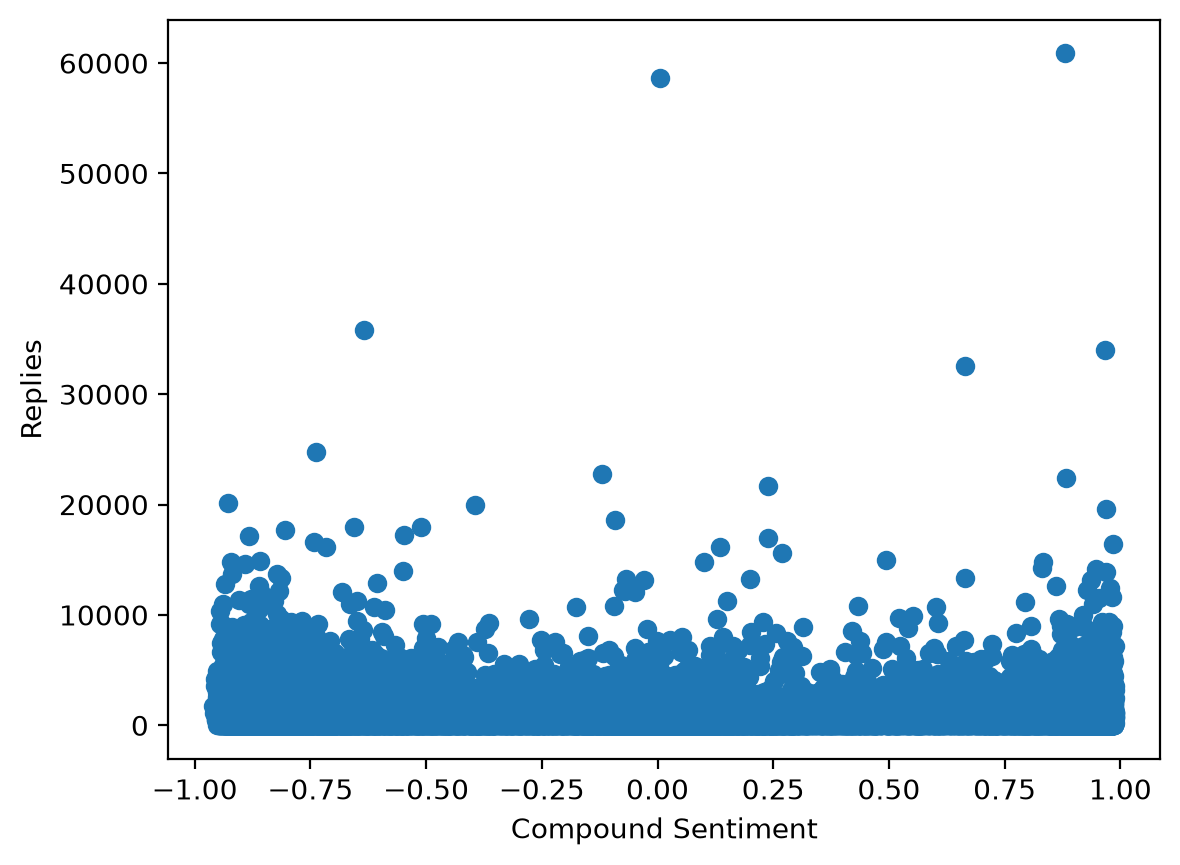

In [23]:
plt.scatter(roberta_sentiment_df["compound"], roberta_sentiment_df["replies_count"])
plt.xlabel("Compound Sentiment")
plt.ylabel("Replies")
plt.show()

## Word Clouds

In [24]:
import nltk
from nltk.corpus import brown
from nltk.tokenize import word_tokenize

from collections import Counter

In [25]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("brown")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\d8amo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\d8amo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\d8amo\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

In [36]:
def clean_text(text):
    # Remove URLs
    text = re.sub(r"https?://\S+", " ", text)

    # Remove RT markers
    text = re.sub(r"\brt\s+@\w+:?|\brt\b", " ", text, flags=re.I)

    # Remove @mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove hashtags but keep the word
    text = re.sub(r"#(\w+)", r"\1", text)

    # Normalize apostrophes
    text = text.replace("’", "'")

    # Remove 's (possessive)
    return text.replace("'s", "")


In [37]:
from nltk.tokenize.regexp import RegexpTokenizer

tokenizer = RegexpTokenizer(r"[A-Za-z]+(?:'[A-Za-z]+)?")

brown_text = " ".join(brown.words()).lower()
brown_text = clean_text(brown_text)
brown_tokens = tokenizer.tokenize(brown_text)

brown_counts = Counter(brown_tokens)
brown_total = sum(brown_counts.values())

In [43]:
def biglyest_words(df):
    all_text = clean_text(df.dropna(subset=["content"])["content"].str.cat(sep=" ").lower())

    tokens = tokenizer.tokenize(all_text)

    doc_counts = Counter(tokens)
    doc_total = sum(doc_counts.values())

    v = len(brown_counts)

    scores = {}

    for word, count in doc_counts.items():
        p_doc = (count + 1) / (doc_total + v)
        p_brown = (brown_counts[word] + 1) / (brown_total + v)

        scores[word] = np.log2(p_doc / p_brown)

    return scores

In [44]:
trump_words = biglyest_words(posts_df)

C:\Users\d8amo\AppData\Local\Temp\ipykernel_10280\382500123.py:43: RuntimeWarning: divide by zero encountered in log
  - np.log((y_brown + a) / (brown_total + alpha0 - y_brown - a))


ZeroDivisionError: division by zero

In [ ]:
trump_sorted = sorted(trump_words, key=trump_words.get, reverse=True)

In [41]:
print("Top 25 words:")
print(trump_sorted[:25])

print("Bottom 25 words:")
print(trump_sorted[-25:])

Top 25 words:
['trump', 'biden', 'maga', 'kamala', 'djt', 'endorsement', 'amp', 'tariffs', 'usa', 'doj', 'hoax', 'rino', 'ukraine', 'lago', 'cnn', 'tirelessly', 'crooked', 'desanctimonious', 'obama', 'foxnews', 'vets', 'scam', 'iran', 'desantis', 'engoron']
Bottom 25 words:
['adequate', 'significance', 'metal', 'experiments', 'fingers', 'shall', 'electronic', 'lips', 'forty', 'smiled', 'horses', 'mercer', 'procedure', 'providence', 'cells', 'feed', 'gray', 'techniques', 'teeth', 'cent', 'thirty', 'literature', 'bed', 'temperature', 'mrs']


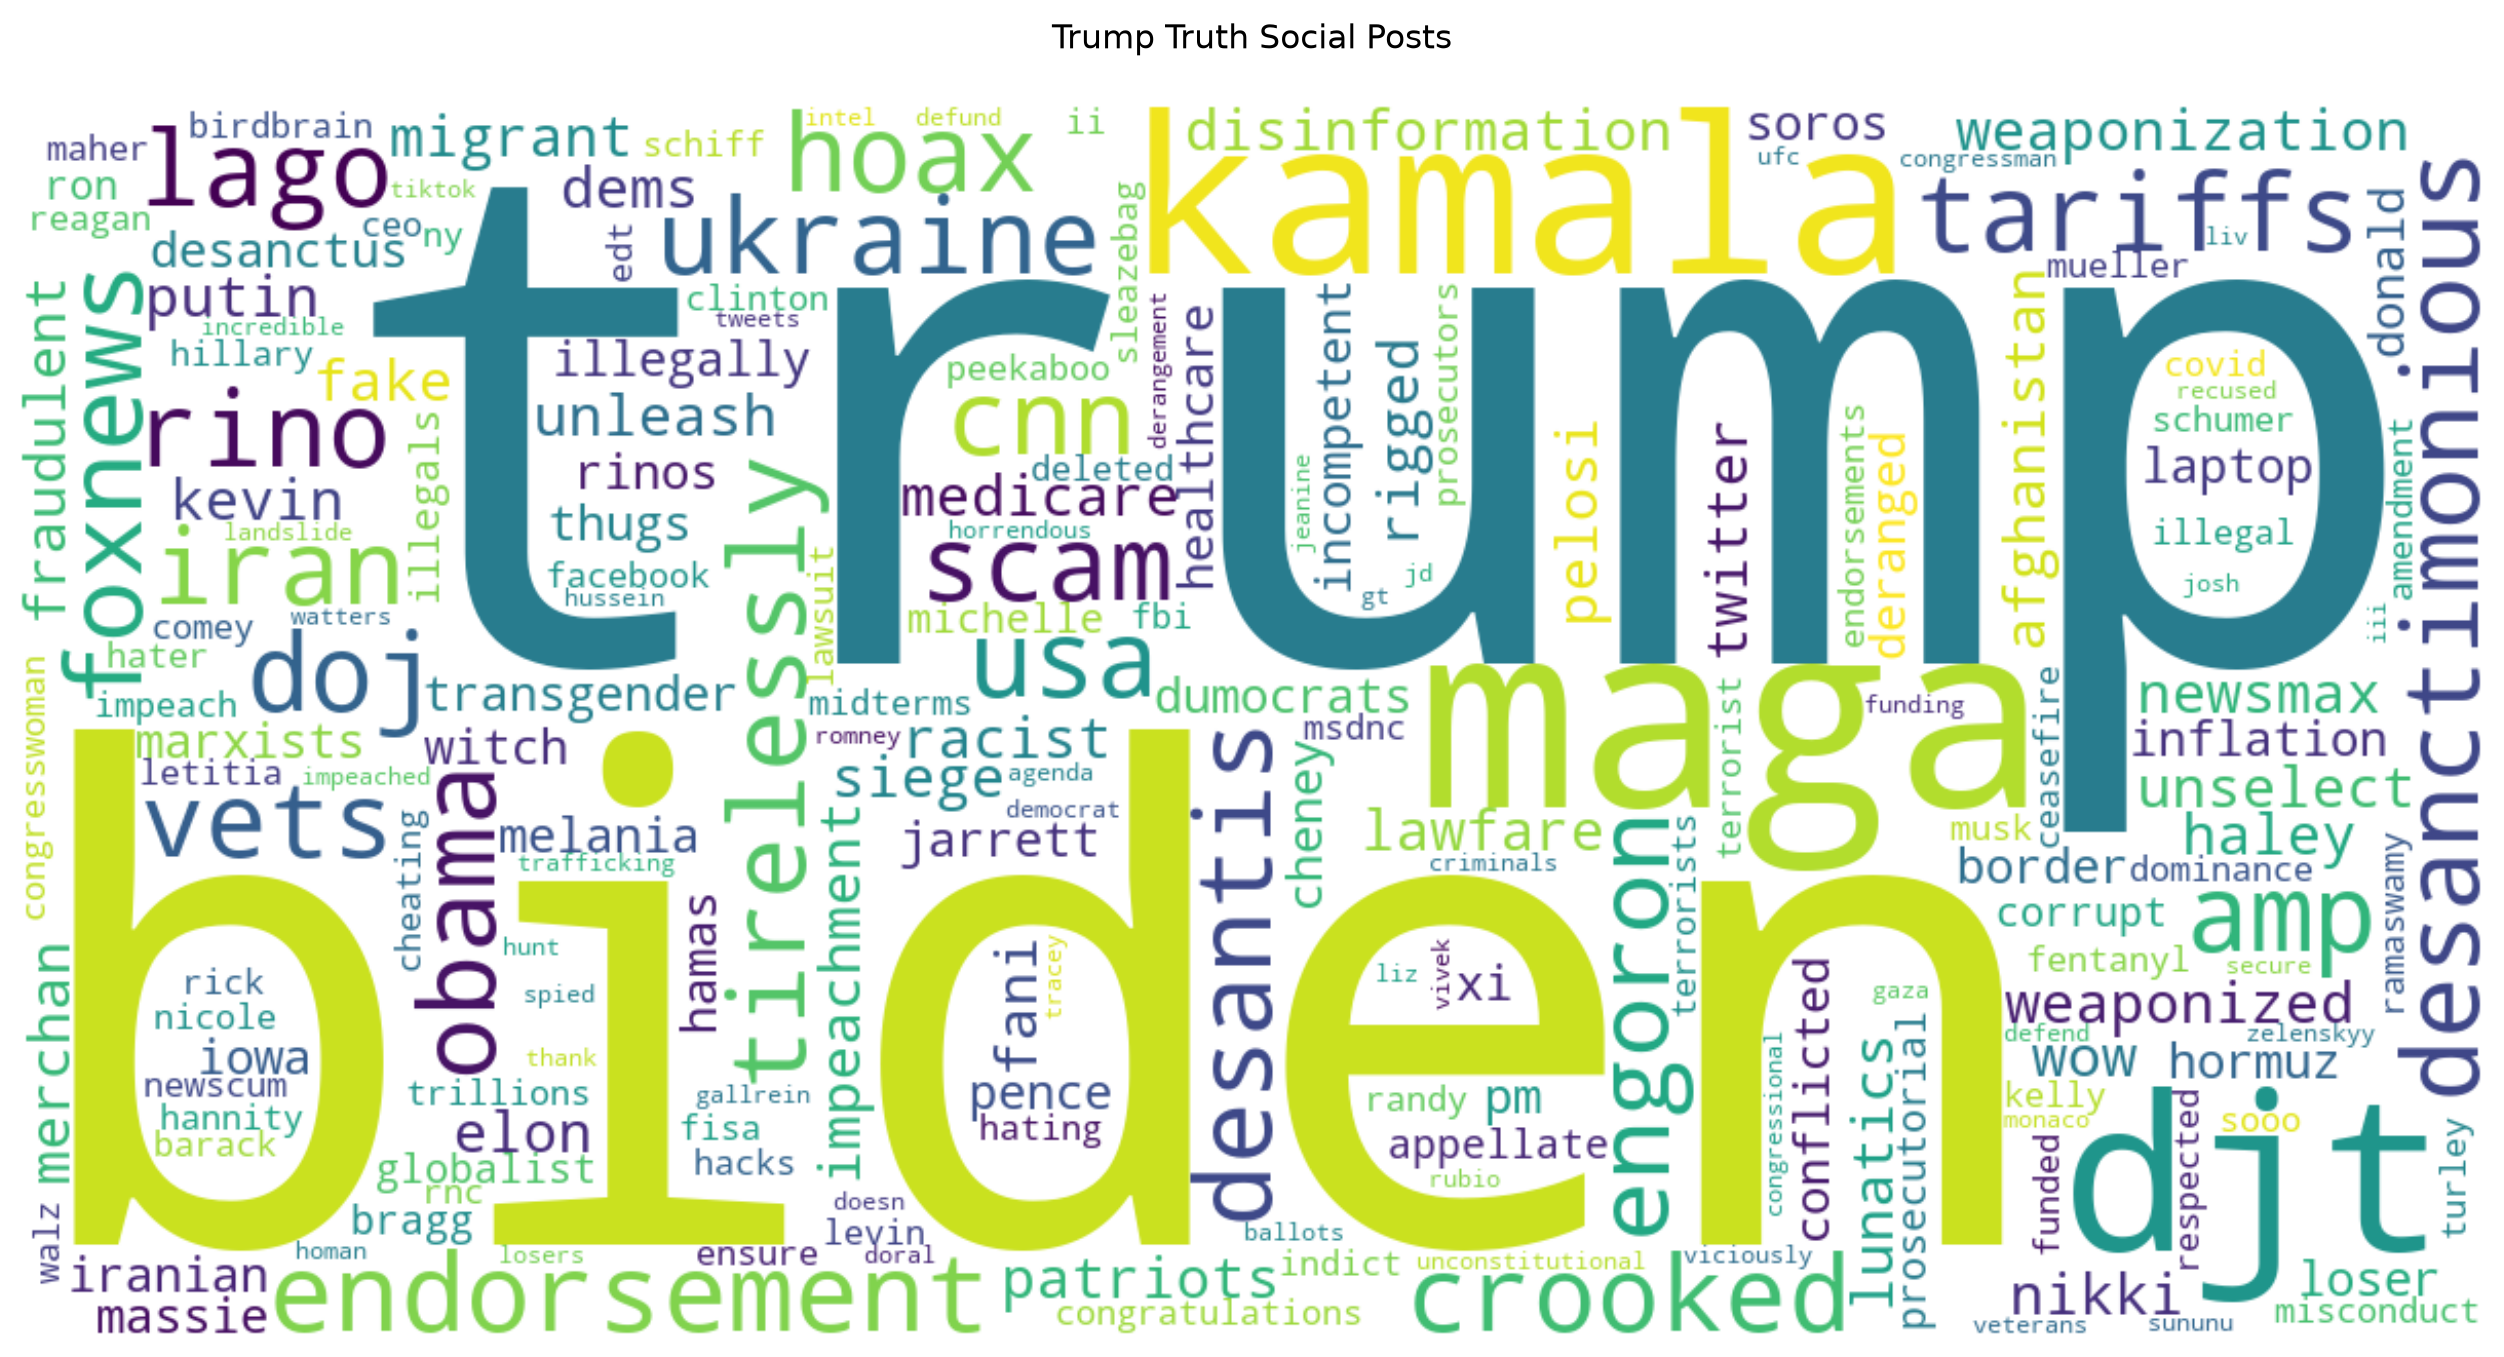

In [42]:
from wordcloud import WordCloud

top = dict(
    sorted(trump_words.items(), key=lambda x: x[1], reverse=True)[:100]
)

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
)

wc.generate_from_frequencies(trump_words)

plt.figure(figsize=(16, 8))
plt.title("Trump Truth Social Posts\n")
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()